# Notebook 15 — Signals & Systems: Practical Applications

Real-world engineering applications of the Laplace transform:
1. RLC circuit analysis (transient & steady-state)
2. Spring-mass-damper vibration analysis
3. Analog filter design (Butterworth, Chebyshev)
4. Laplace vs Fourier comparison
5. Sampling theorem and aliasing in the s-domain

Underdamped  (zeta=0.1): wn=1.41, zeta=0.71, resonance=None
Critical     (zeta=1.0): wn=2.00, zeta=1.00, resonance=None
Overdamped   (zeta=2.0): wn=2.00, zeta=4.00, resonance=None


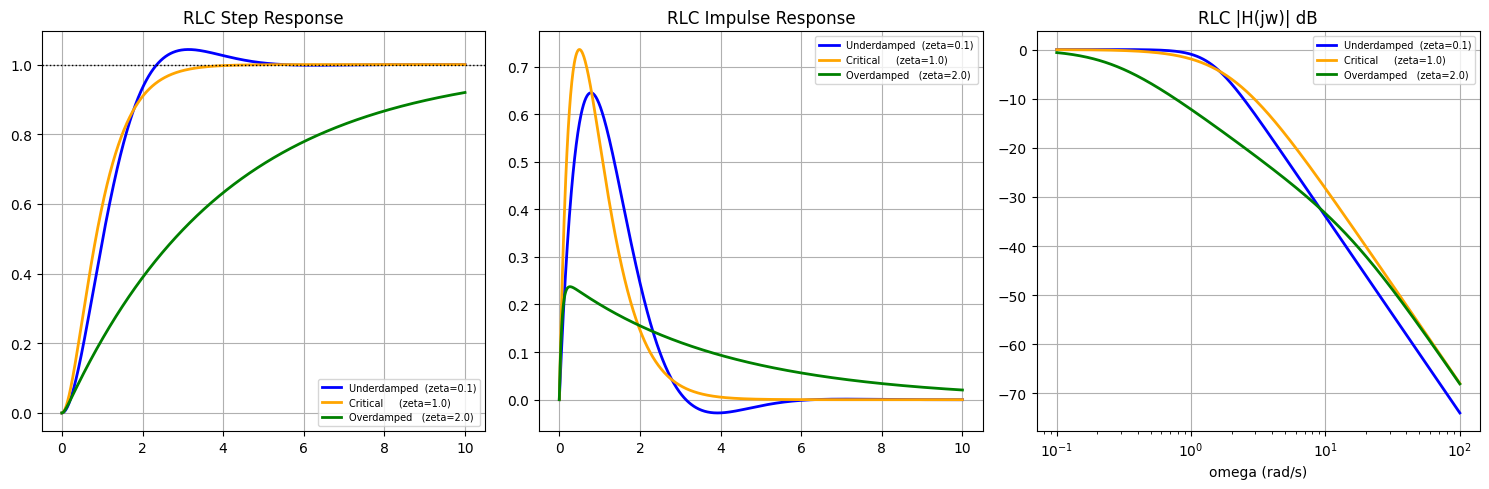

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# RLC Series Circuit
# H(s) = V_C/V_in = wn^2 / (s^2 + 2*zeta*wn*s + wn^2)
# wn = 1/sqrt(LC),  zeta = R/(2*sqrt(L/C))

class RLCCircuit:
    def __init__(self, R, L, C):
        self.R, self.L, self.C = R, L, C
        self.wn   = 1.0 / np.sqrt(L*C)
        self.zeta = R / (2*np.sqrt(L/C))
        self._sys = signal.TransferFunction([self.wn**2], [1, 2*self.zeta*self.wn, self.wn**2])

    def step_response(self, t):     return signal.step(self._sys, T=t)[1]
    def impulse_response(self, t):  return signal.impulse(self._sys, T=t)[1]

    def freq_response(self, omega):
        _, H = signal.freqs([self.wn**2], [1, 2*self.zeta*self.wn, self.wn**2], worN=omega)
        return H

    def poles(self):        return np.roots([1, 2*self.zeta*self.wn, self.wn**2])
    def resonant_freq(self):
        if self.zeta < 1/np.sqrt(2):
            return self.wn*np.sqrt(1 - 2*self.zeta**2)
        return None

circuits = {
    'Underdamped  (zeta=0.1)': RLCCircuit(R=2,   L=1.0, C=0.5),
    'Critical     (zeta=1.0)': RLCCircuit(R=4,   L=1.0, C=0.25),
    'Overdamped   (zeta=2.0)': RLCCircuit(R=16,  L=1.0, C=0.25),
}

t_sim   = np.linspace(0, 10, 1000)
omega   = np.logspace(-1, 2, 400)
colors  = ['blue', 'orange', 'green']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for (name, circ), col in zip(circuits.items(), colors):
    axes[0].plot(t_sim, circ.step_response(t_sim),    color=col, lw=2, label=name)
    axes[1].plot(t_sim, circ.impulse_response(t_sim), color=col, lw=2, label=name)
    H = circ.freq_response(omega)
    axes[2].semilogx(omega, 20*np.log10(np.abs(H)+1e-12), color=col, lw=2, label=name)
    f_res = circ.resonant_freq()
    print(f'{name}: wn={circ.wn:.2f}, zeta={circ.zeta:.2f}, resonance={f_res}')

axes[0].axhline(1.0, color='k', ls=':', lw=1)
for ax, title in zip(axes, ['Step Response', 'Impulse Response', '|H(jw)| dB']):
    ax.set_title(f'RLC {title}'); ax.legend(fontsize=7); ax.grid(True)
axes[2].set_xlabel('omega (rad/s)')
plt.tight_layout(); plt.show()


Spring-mass-damper: wn=2.00 rad/s, zeta=0.100


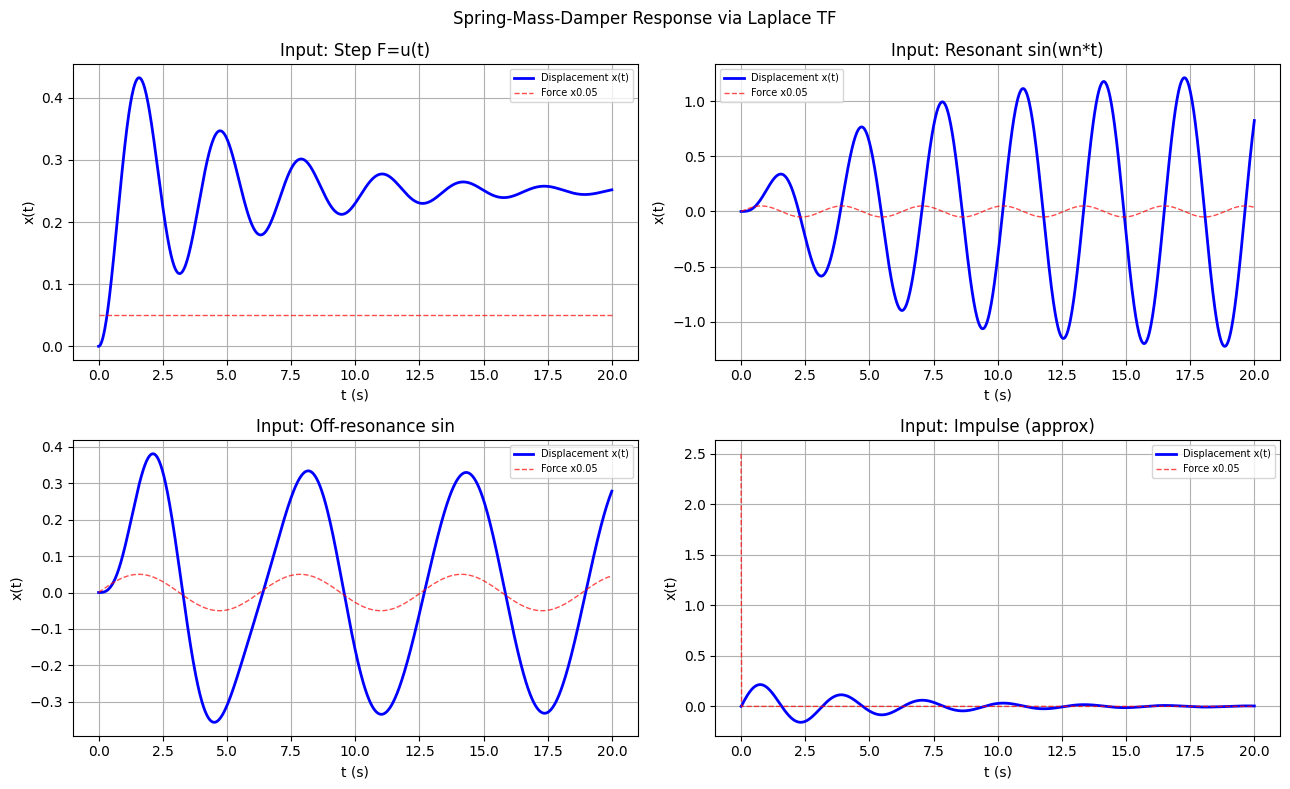

In [2]:
# Spring-Mass-Damper Mechanical System
# m*x'' + c*x' + k*x = F(t)
# H(s) = X(s)/F(s) = (1/m) / (s^2 + (c/m)*s + k/m)

class SpringMassDamper:
    def __init__(self, m, c, k):
        self.m, self.c, self.k = m, c, k
        self.wn   = np.sqrt(k/m)
        self.zeta = c / (2*np.sqrt(m*k))
        self._sys = signal.TransferFunction([1/m], [1, c/m, k/m])

    def response(self, F_func, t):
        _, x, _ = signal.lsim(self._sys, F_func(t), t)
        return x

sys_mech = SpringMassDamper(m=1.0, c=0.4, k=4.0)
print(f'Spring-mass-damper: wn={sys_mech.wn:.2f} rad/s, zeta={sys_mech.zeta:.3f}')

t_mech = np.linspace(0, 20, 1000)
forces = {
    'Step F=u(t)':        lambda t: np.ones_like(t),
    'Resonant sin(wn*t)': lambda t: np.sin(sys_mech.wn*t),
    'Off-resonance sin':  lambda t: np.sin(0.5*sys_mech.wn*t),
    'Impulse (approx)':   lambda t: np.where(t < 0.02, 50.0, 0.0),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (fname, F_func) in zip(axes.ravel(), forces.items()):
    x = sys_mech.response(F_func, t_mech)
    ax.plot(t_mech, x,                   'b-', lw=2, label='Displacement x(t)')
    ax.plot(t_mech, F_func(t_mech)*0.05, 'r--', lw=1, alpha=0.7, label='Force x0.05')
    ax.set_title(f'Input: {fname}'); ax.legend(fontsize=7); ax.grid(True)
    ax.set_xlabel('t (s)'); ax.set_ylabel('x(t)')

plt.suptitle('Spring-Mass-Damper Response via Laplace TF', fontsize=12)
plt.tight_layout(); plt.show()


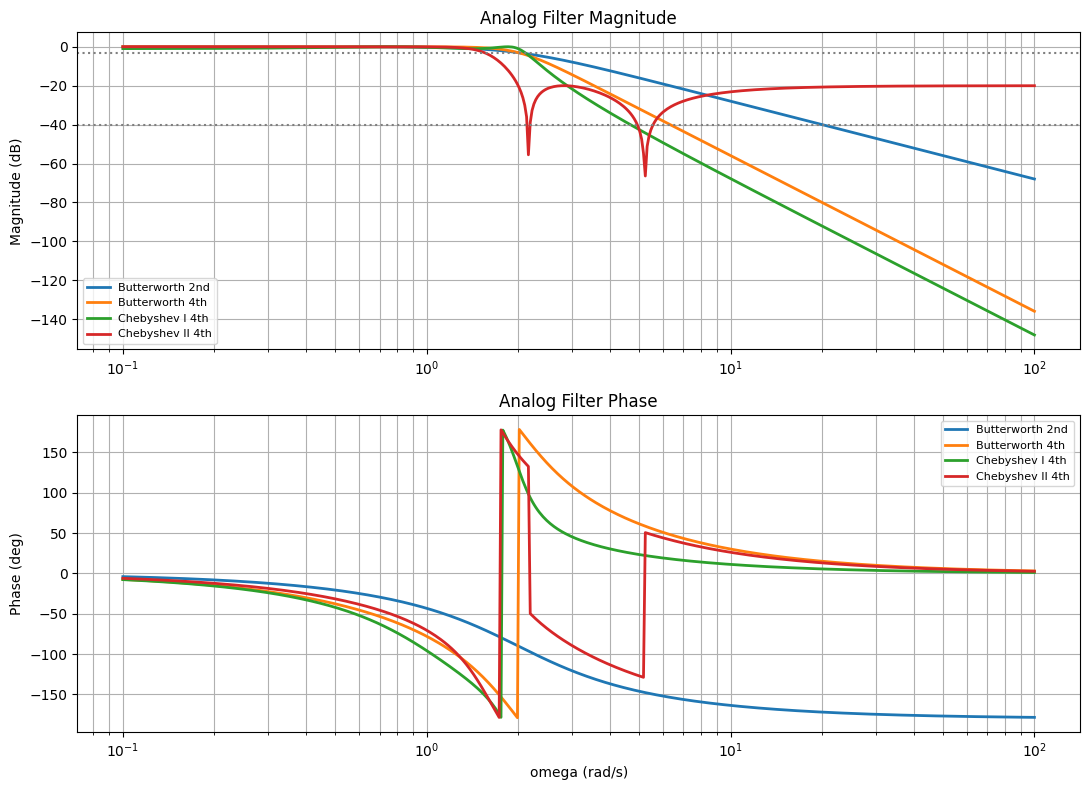

Pole locations:
  Butterworth 2nd         max Re(pole)=-1.4142  stable=True
  Butterworth 4th         max Re(pole)=-0.7654  stable=True
  Chebyshev I 4th         max Re(pole)=-0.2791  stable=True
  Chebyshev II 4th        max Re(pole)=-0.4113  stable=True


In [3]:
# Analog Filter Design in the Laplace Domain
filter_designs = [
    ('Butterworth 2nd', *signal.butter(2, 2.0, btype='low', analog=True, output='ba')),
    ('Butterworth 4th', *signal.butter(4, 2.0, btype='low', analog=True, output='ba')),
    ('Chebyshev I 4th', *signal.cheby1(4, 1.0, 2.0, btype='low', analog=True, output='ba')),
    ('Chebyshev II 4th',*signal.cheby2(4, 20., 2.0, btype='low', analog=True, output='ba')),
]

omega = np.logspace(-1, 2, 500)
fig, axes = plt.subplots(2, 1, figsize=(11, 8))
for name, b, a in filter_designs:
    _, H = signal.freqs(b, a, worN=omega)
    axes[0].semilogx(omega, 20*np.log10(np.abs(H)+1e-12), lw=2, label=name)
    axes[1].semilogx(omega, np.angle(H, deg=True), lw=2, label=name)

axes[0].axhline(-3,  color='gray', ls=':')
axes[0].axhline(-40, color='gray', ls=':')
axes[0].set_ylabel('Magnitude (dB)'); axes[0].set_title('Analog Filter Magnitude')
axes[0].legend(fontsize=8); axes[0].grid(True, which='both')
axes[1].set_xlabel('omega (rad/s)'); axes[1].set_ylabel('Phase (deg)')
axes[1].set_title('Analog Filter Phase')
axes[1].legend(fontsize=8); axes[1].grid(True, which='both')
plt.tight_layout(); plt.show()

# Print pole locations
print('Pole locations:')
for name, b, a in filter_designs:
    poles = np.roots(a)
    max_real = np.max(np.real(poles))
    print(f'  {name:<22}  max Re(pole)={max_real:.4f}  stable={max_real<0}')


In [4]:
# Laplace vs Fourier: comprehensive comparison with demonstration
print('='*68)
print('LAPLACE TRANSFORM vs FOURIER TRANSFORM')
print('='*68)
comparison = [
    ('Integration range',    '0 to +inf (causal)',       '-inf to +inf'),
    ('Transform variable',   's = sigma + j*omega',      'omega (real only)'),
    ('Encodes initial conds','Yes, naturally',            'No'),
    ('Stability analysis',   'Yes -- pole positions',    'Not directly'),
    ('Unstable signals',     'OK if ROC exists',         'Cannot transform'),
    ('Link to each other',   'F(j*omega)=L{f}|_{s=jw}', '(same -- special case)'),
    ('FFT available',        'No (must invert numerically)', 'Yes: O(N log N)'),
    ('Typical use',          'Control, transient ODE',   'Spectra, filtering, PSD'),
]
print(f'  {"Property":<25} {"Laplace":>20} {"Fourier":>18}')
print('  '+'-'*65)
for prop, lap, four in comparison:
    print(f'  {prop:<25} {lap:>20} {four:>18}')

# Demonstrate the Laplace-Fourier connection on imaginary axis
print()
print('Demonstration: F(s)|_{s=jw} = Fourier{f}(omega)')
f_demo = lambda t: np.exp(-t) * np.where(np.asarray(t)>=0, 1., 0.)
omega_demo = np.array([0.0, 1.0, 2.0, 5.0])
for w in omega_demo:
    F_lap  = 1/(1j*w + 1)          # analytic: 1/(s+1) at s=jw
    F_four = 1/(1j*w + 1)          # same formula -- that's the point!
    print(f'  omega={w}: |F(jw)| = {abs(F_lap):.4f}  (Laplace = Fourier on jw-axis)')


LAPLACE TRANSFORM vs FOURIER TRANSFORM
  Property                               Laplace            Fourier
  -----------------------------------------------------------------
  Integration range           0 to +inf (causal)       -inf to +inf
  Transform variable         s = sigma + j*omega  omega (real only)
  Encodes initial conds           Yes, naturally                 No
  Stability analysis        Yes -- pole positions       Not directly
  Unstable signals              OK if ROC exists   Cannot transform
  Link to each other        F(j*omega)=L{f}|_{s=jw} (same -- special case)
  FFT available             No (must invert numerically)    Yes: O(N log N)
  Typical use               Control, transient ODE Spectra, filtering, PSD

Demonstration: F(s)|_{s=jw} = Fourier{f}(omega)
  omega=0.0: |F(jw)| = 1.0000  (Laplace = Fourier on jw-axis)
  omega=1.0: |F(jw)| = 0.7071  (Laplace = Fourier on jw-axis)
  omega=2.0: |F(jw)| = 0.4472  (Laplace = Fourier on jw-axis)
  omega=5.0: |F(jw)| = 

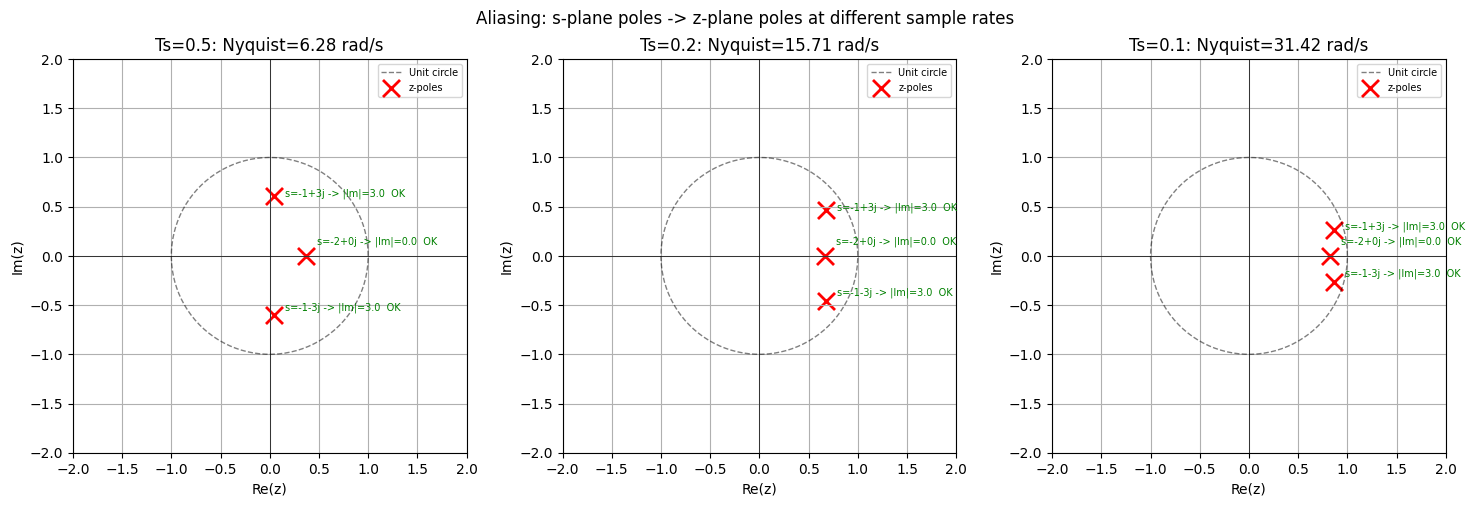

Sampling condition: |Im(s_pole)| < pi/Ts  for alias-free mapping
  s=(-1+3j), Ts=0.5: Nyquist=6.28, |Im(s)|=3.0 -> OK
  s=(-1+3j), Ts=0.2: Nyquist=15.71, |Im(s)|=3.0 -> OK
  s=(-1+3j), Ts=0.1: Nyquist=31.42, |Im(s)|=3.0 -> OK
  s=(-1-3j), Ts=0.5: Nyquist=6.28, |Im(s)|=3.0 -> OK
  s=(-1-3j), Ts=0.2: Nyquist=15.71, |Im(s)|=3.0 -> OK
  s=(-1-3j), Ts=0.1: Nyquist=31.42, |Im(s)|=3.0 -> OK
  s=(-2+0j), Ts=0.5: Nyquist=6.28, |Im(s)|=0.0 -> OK
  s=(-2+0j), Ts=0.2: Nyquist=15.71, |Im(s)|=0.0 -> OK
  s=(-2+0j), Ts=0.1: Nyquist=31.42, |Im(s)|=0.0 -> OK


In [5]:
# Sampling in the s-domain: aliasing via pole replication
# When sampling f(t) at rate Ts, the z-transform poles are z=exp(s_k*Ts)
# Aliasing occurs when Im(s_k*Ts) wraps around -- i.e., |Im(s_k)| > pi/Ts

Ts_vals = [0.5, 0.2, 0.1]
s_poles_analog = np.array([-1+3j, -1-3j, -2+0j])  # analog poles

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, Ts in zip(axes, Ts_vals):
    Nyquist = np.pi / Ts
    z_poles = np.exp(s_poles_analog * Ts)

    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=1, alpha=0.5, label='Unit circle')
    ax.scatter(z_poles.real, z_poles.imag, s=150, marker='x', c='red', lw=2, label='z-poles')

    for i, (sp, zp) in enumerate(zip(s_poles_analog, z_poles)):
        alias_ok = abs(np.imag(sp)) < Nyquist
        color = 'green' if alias_ok else 'red'
        label_txt = f's={sp:.0f} -> |Im|={abs(np.imag(sp)):.1f}  {"OK" if alias_ok else "ALIASED"}'
        ax.annotate(label_txt, (zp.real, zp.imag), textcoords='offset points',
                    xytext=(8, 4*i), fontsize=7, color=color)

    ax.set_title(f'Ts={Ts}: Nyquist={Nyquist:.2f} rad/s')
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.legend(fontsize=7); ax.grid(True); ax.set_aspect('equal')

plt.suptitle('Aliasing: s-plane poles -> z-plane poles at different sample rates')
plt.tight_layout(); plt.show()

print('Sampling condition: |Im(s_pole)| < pi/Ts  for alias-free mapping')
for sp in s_poles_analog:
    for Ts in Ts_vals:
        ok = abs(np.imag(sp)) < np.pi/Ts
        print(f'  s={sp}, Ts={Ts}: Nyquist={np.pi/Ts:.2f}, |Im(s)|={abs(np.imag(sp)):.1f} -> {"OK" if ok else "ALIASED"}')
